In [1]:
#Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load dataset
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
#Understanding the dataset

# Dataset information
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [ ]:
# Statistical summary
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [5]:

# Number of rows and columns
df.shape

(1000, 8)

# Data Preprocessing


In [6]:
#Rename Columns: Making column names easier.
df.rename(
    columns={
        "race/ethnicity":"race",
        "parental level of education":"parent_education",
        "test preparation course":"test_preparation",
        "math score":"math_score",
        "reading score":"reading_score",
        "writing score":"writing_score"
    },
    inplace=True
)

df.head()

,gender,race,parent_education,lunch,test_preparation,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [7]:
#Check Missing Values
df.isnull().sum()

gender              0
race                0
parent_education    0
lunch               0
test_preparation    0
math_score          0
reading_score       0
writing_score       0
dtype: int64

In [8]:
#Check Duplicate Values
df.duplicated().sum()

np.int64(0)

In [ ]:
#Remove Duplicate Values
#df.drop_duplicates(inplace=True)

In [10]:
#Check Datatypes
df.dtypes

gender                str
race                  str
parent_education      str
lunch                 str
test_preparation      str
math_score          int64
reading_score       int64
writing_score       int64
dtype: object

# Feature Engineering

In [13]:
#Creating average score.
df["average_score"] = (
    df["math_score"]+
    df["reading_score"]+
    df["writing_score"]
)/3


df.head()


,gender,race,parent_education,lunch,test_preparation,math_score,reading_score,writing_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


# Univariate Analysis


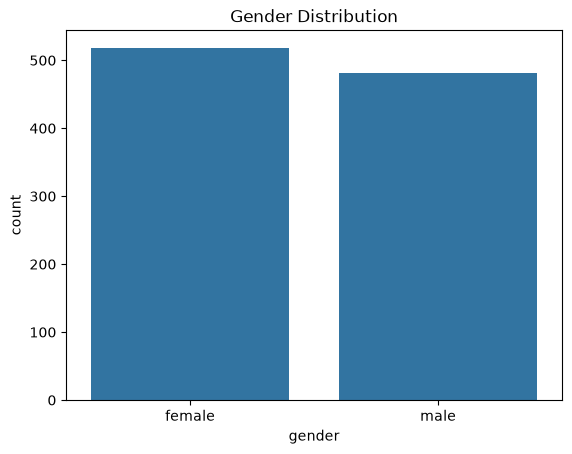

In [14]:
#Gender Distribution

sns.countplot(
    x="gender",
    data=df
)

plt.title("Gender Distribution")
plt.show()

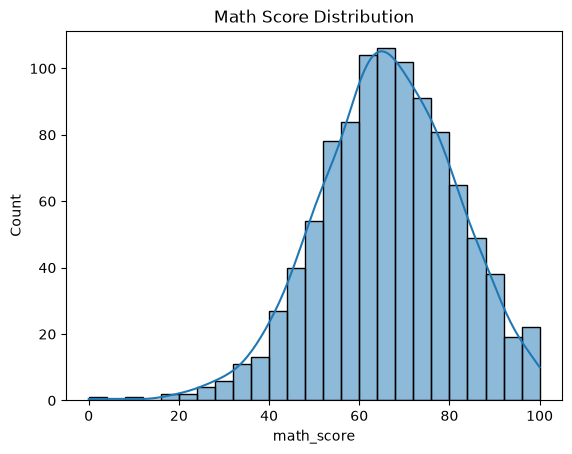

In [15]:
# Math Score Distribution
sns.histplot(
    df["math_score"],
    kde=True
)

plt.title("Math Score Distribution")

plt.show()

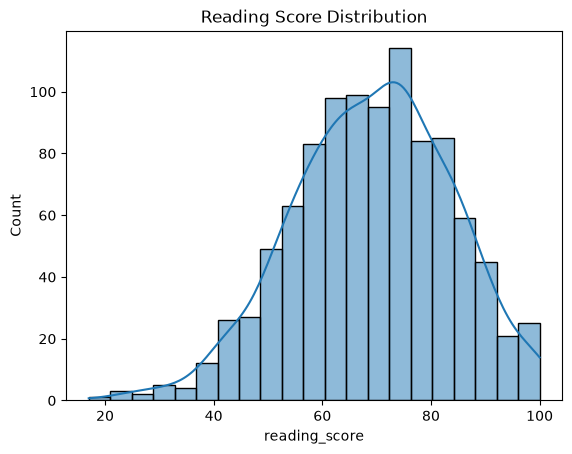

In [16]:
# Reading Score Distribution
sns.histplot(
    df["reading_score"],
    kde=True
)

plt.title("Reading Score Distribution")

plt.show()

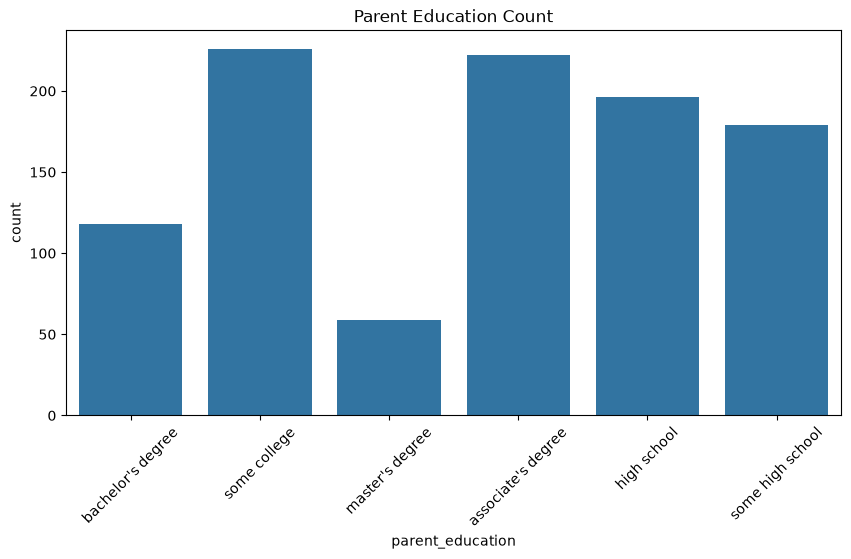

In [18]:
# Parental Education Analysis
plt.figure(figsize=(10,5))
sns.countplot(
    x="parent_education",
    data=df
)
plt.xticks(rotation=45)
plt.title("Parent Education Count")
plt.show()

# Bivariate Analysis


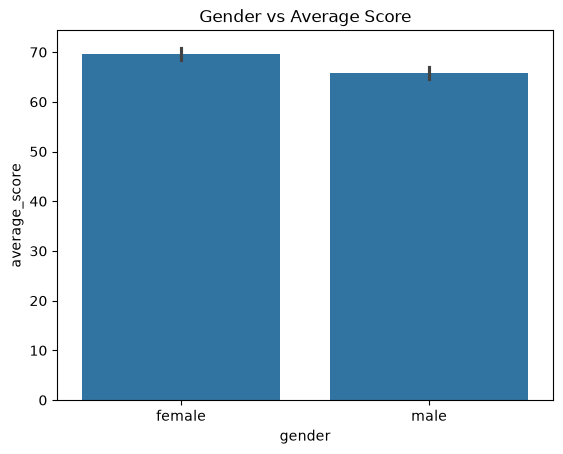

In [19]:
# Gender vs Average Score
sns.barplot(
    x="gender",
    y="average_score",
    data=df
)

plt.title(
"Gender vs Average Score"
)

plt.show()

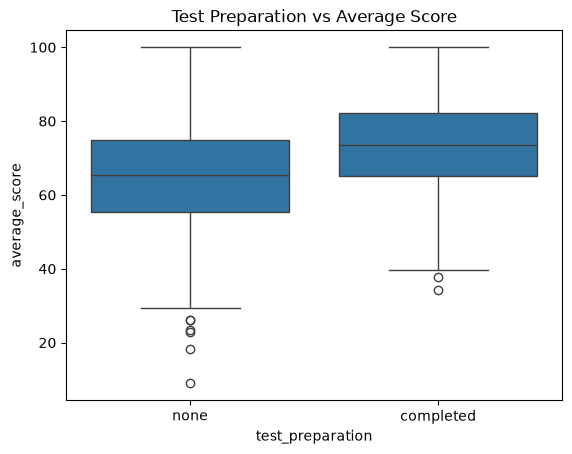

In [20]:
# Test Preparation vs Marks
sns.boxplot(
    x="test_preparation",
    y="average_score",
    data=df
)
plt.title("Test Preparation vs Average Score")
plt.show()

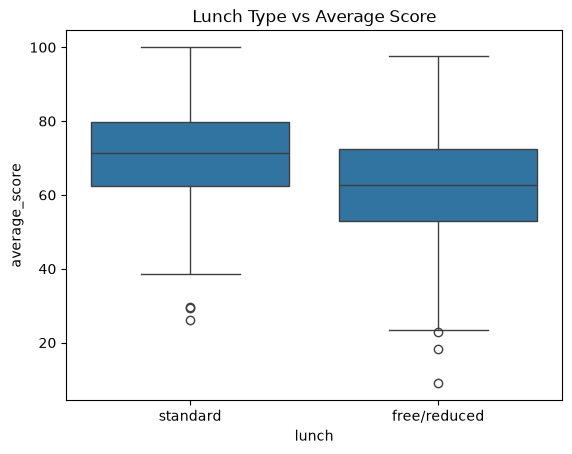

In [21]:
# Lunch Type vs Performance
sns.boxplot(
    x="lunch",
    y="average_score",
    data=df
)
plt.title("Lunch Type vs Average Score")
plt.show()

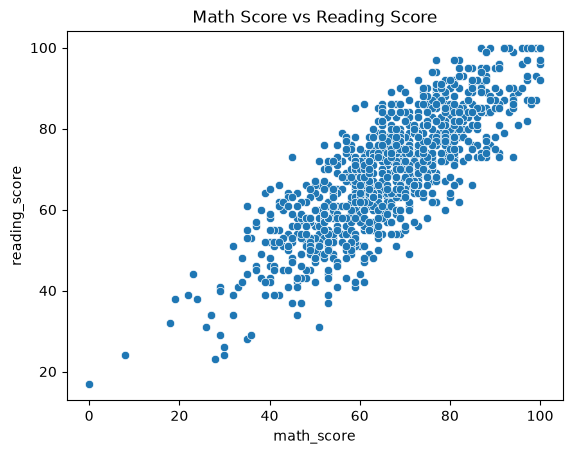

In [22]:
# Math vs Reading Score
sns.scatterplot(
    x="math_score",
    y="reading_score",
    data=df
)
plt.title("Math Score vs Reading Score")
plt.show()

# Multivariate Analysis


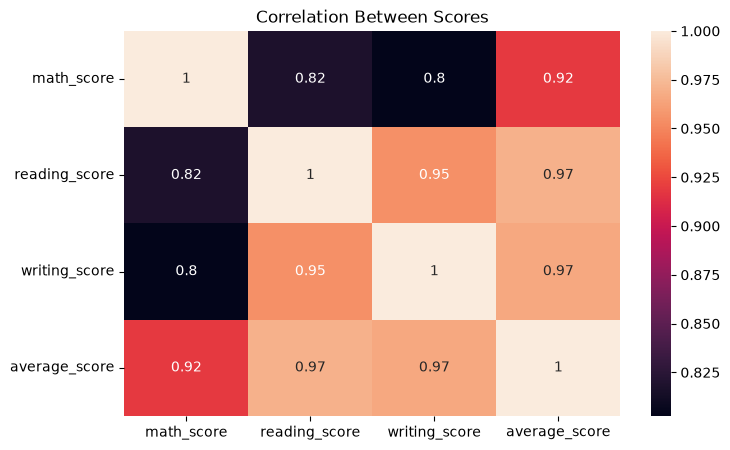

In [24]:
# Correlation Heatmap
plt.figure(figsize=(8,5))


sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

plt.title(
"Correlation Between Scores"
)

plt.show()

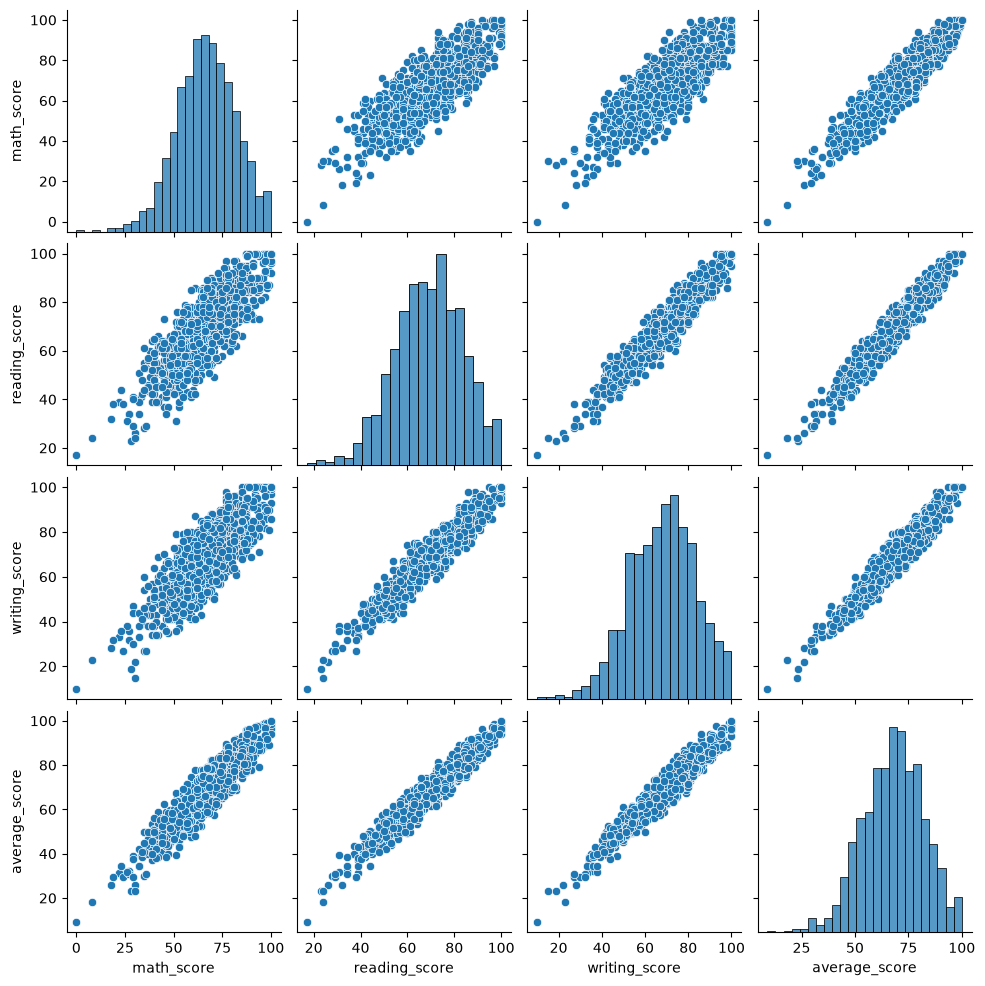

In [ ]:
# Pair Plot

sns.pairplot(
    df[
        [
            "math_score",
            "reading_score",
            "writing_score",
            "average_score"
        ]
    ]
    )

plt.show()

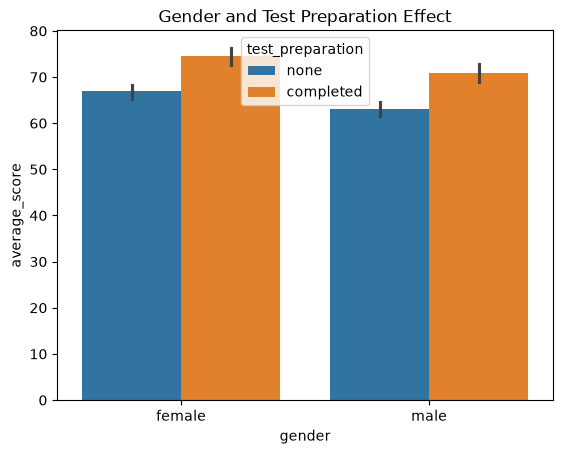

In [27]:
# Gender + Test Preparation + Score
sns.barplot(
    x="gender",
    y="average_score",
    hue="test_preparation",
    data=df
)

plt.title(
"Gender and Test Preparation Effect"
)

plt.show()

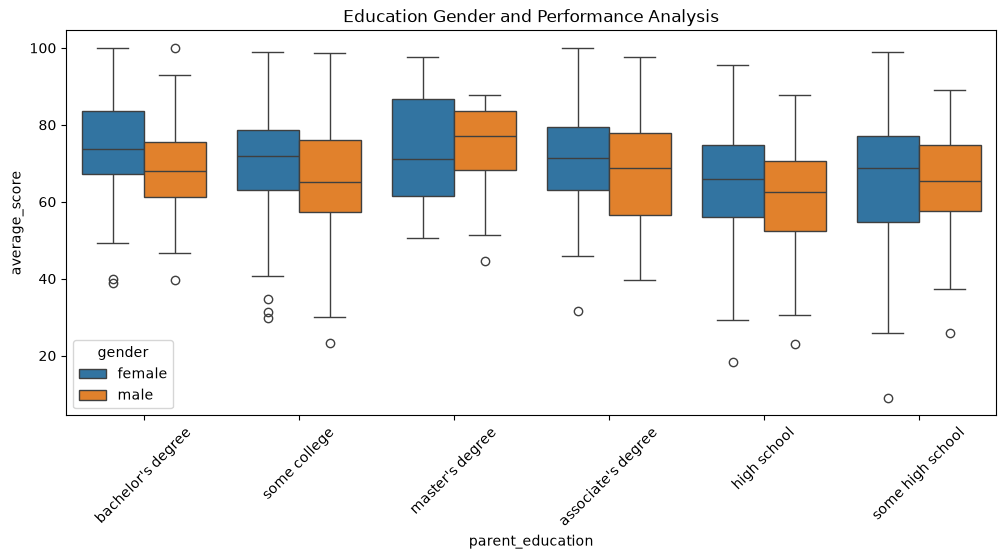

In [28]:
# Parent Education + Gender + Marks
plt.figure(figsize=(12,5))
sns.boxplot(
    x="parent_education",
    y="average_score",
    hue="gender",
    data=df
)
plt.xticks(rotation=45)

plt.title(
"Education Gender and Performance Analysis"
)
plt.show()